<a href="https://colab.research.google.com/github/realtommypoole/LLMRAGOptimize/blob/Dev-Branch/AAI_590_TommyPoole_CodeWithOutputs_cleared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: LLM RAG Distillation & Supervised Fine Tuning Optimization
## Subtitle: Fine tuning open source nano models with larger reasoning models
Author: Tommy Poole, Spring Semester 2026, University of San Diego, Shirley Marcos School of Engineering, Master's in Science of Applied Artificial Intelligence

**Attribution:** The following AI tools were referenced for intial code drafting, as well as review, and troubleshooting through the actual development process: Claude Code March-April 2026. Perplexity.ai, accessed March -April 2026. Also Gemini, accessed March-April 2026. Also, Microsoft, [this video](https://learn.microsoft.com/en-us/shows/ai-show/theres-no-reason-not-to-fine-tune-anymore
) was a key inspiration for this line of questioning related to RAG optimization approaches.


Microsoft Citation: Frame, A., More, O., & Juarez, S. (2025, September 8). There's no reason not to fine tune anymore [Video]. Microsoft AI Show. https://learn.microsoft.com/en-us/shows/ai-show/theres-no-reason-not-to-fine-tune-anymore






---



## Introduction, RAG

Retreival Augmented Generation (RAG) helps Large Language Models perform when applied to contexts with specific knowledge, such as enterprise business settings. RAG solutions produce more accurate information by gounding generated answers in a corpus of specific knowledge, vocuabluary, and even wriring style. One way this kind of application can be optimized to produce better answers is with supervised fine-tuning (SFT), where specific information is used to improve the base LLM response. This fine-tuning, coupled with RAG, can achieve even better results than RAG alone. One of the key questions is how much fine-tuning data is needed to improve results.

### RAG Overview Graphic

**Attribution:** this graphic was made from text the author supplied to Claude, and refined through multiple iterations to organize in this diagram.

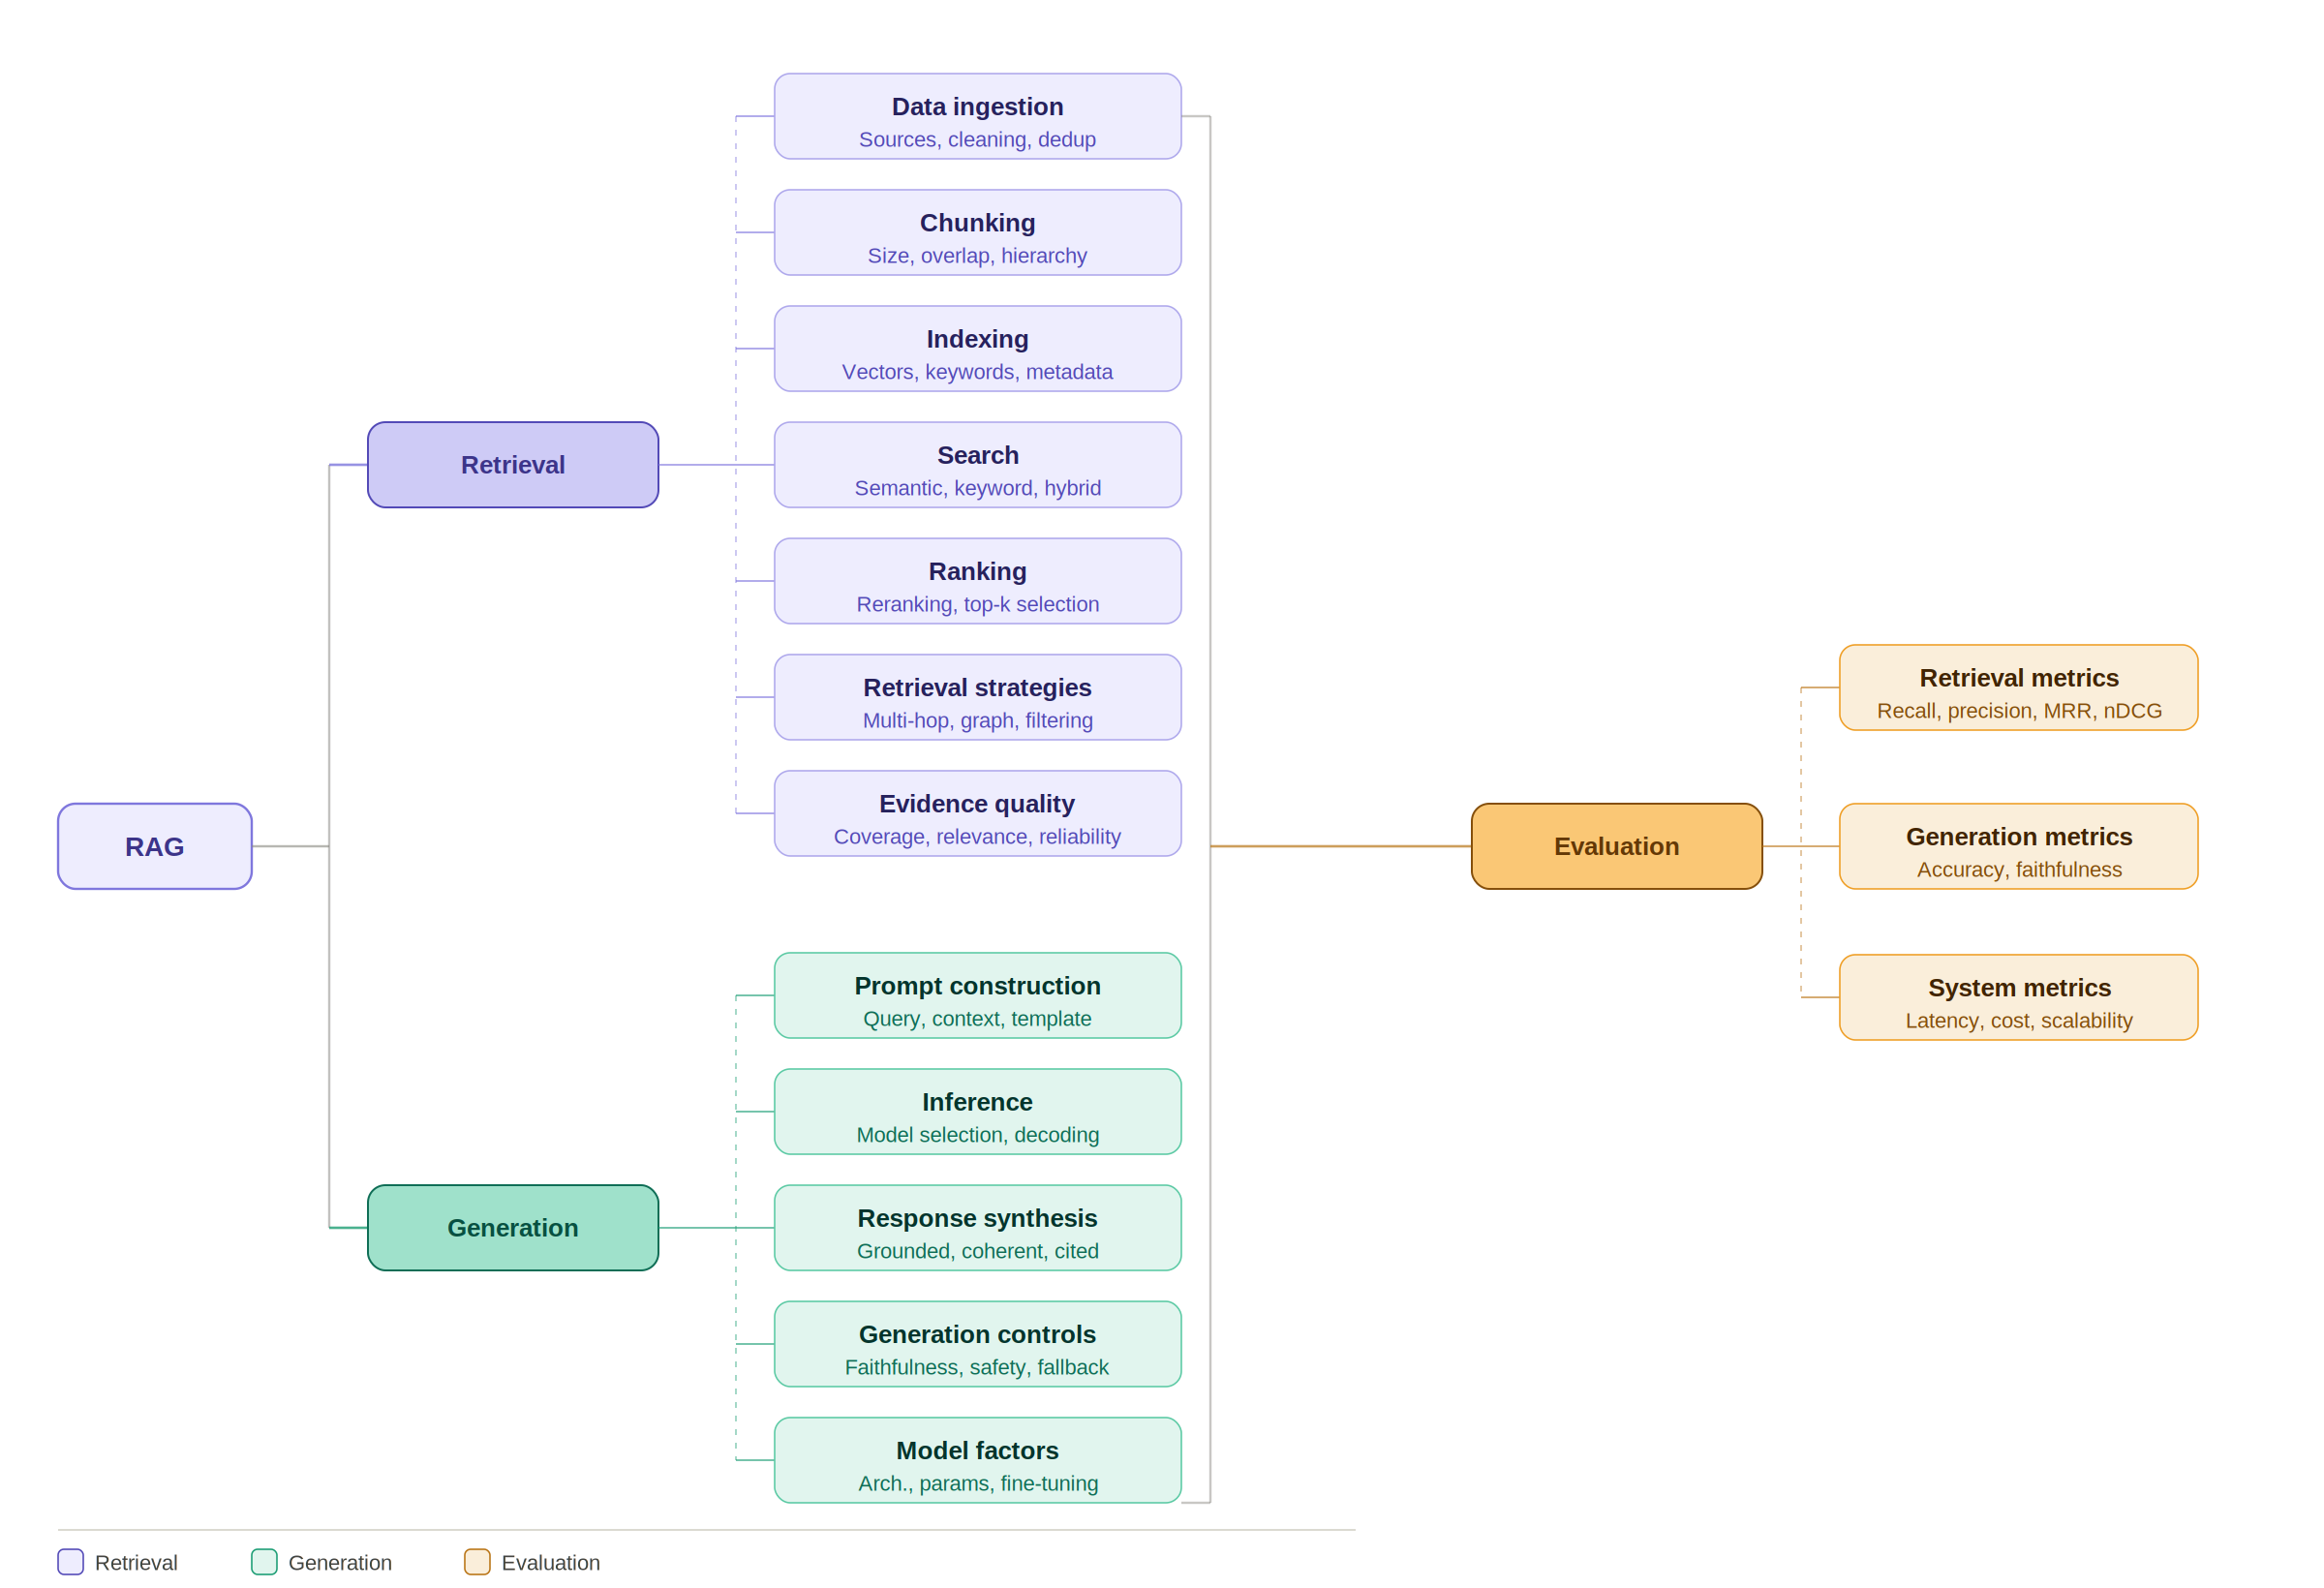

### Project Outline

This project compares-fine tuning with different amounts of data across different models. The code is outlined as follows:

1. Import key libraries.
2. Download models from HuggingFace
  - Medium Sized Reasoning Model (DeepSeek-R1-Distill-Qwen-14B )
  - Nano Models for training (SmolLM3-3B, Nemotron 3 Nano-4B, Llama-3.2-1B-Instruct)
  - Connect API to Frontier Model, Claude 4.6 for comparison, knowledge distillaiton, and evaluation scoring
3. Upload or ingest a corpus of data.
4. Generate text embeddings, store in vector store.
5. Use frontier model to create question answer pairs each based on the corpus, convert to JSONL format and combine in one dataset.
6. Create four datasets from those total questions of QA pairs for fine tuning of the following sizes: (40 held out as test), then 256 QA pairs, 64 QA pairs, and 8 QA pairs.
7. Train: Fine-tune all three nano models with the question answer pairs of varying sized datasets.
8. Generate Responses: Generate responses with trained models, and base models: Generate responses to the 40 held out questions with the three fine-tuned models, and all three non fine-tuned models base nano, with the same prompt and corpus for reitreival. Also generate answers with reasoning and frontier models against the same questions.
9. Evaluate: Use frontier model to evaluate each response against the ground truth for groundedness, relevance, and response completeness based on Microsoft documentation to determine scores on a 1-5 scale.
10. Visualize results.
11. Discuss results. The primary question for evaluation is whether or not the total number of questions used impacts the fine tuning results.


### Project Outline Flow
Attribution: Created with the aide of Claude Sonnet 4.6

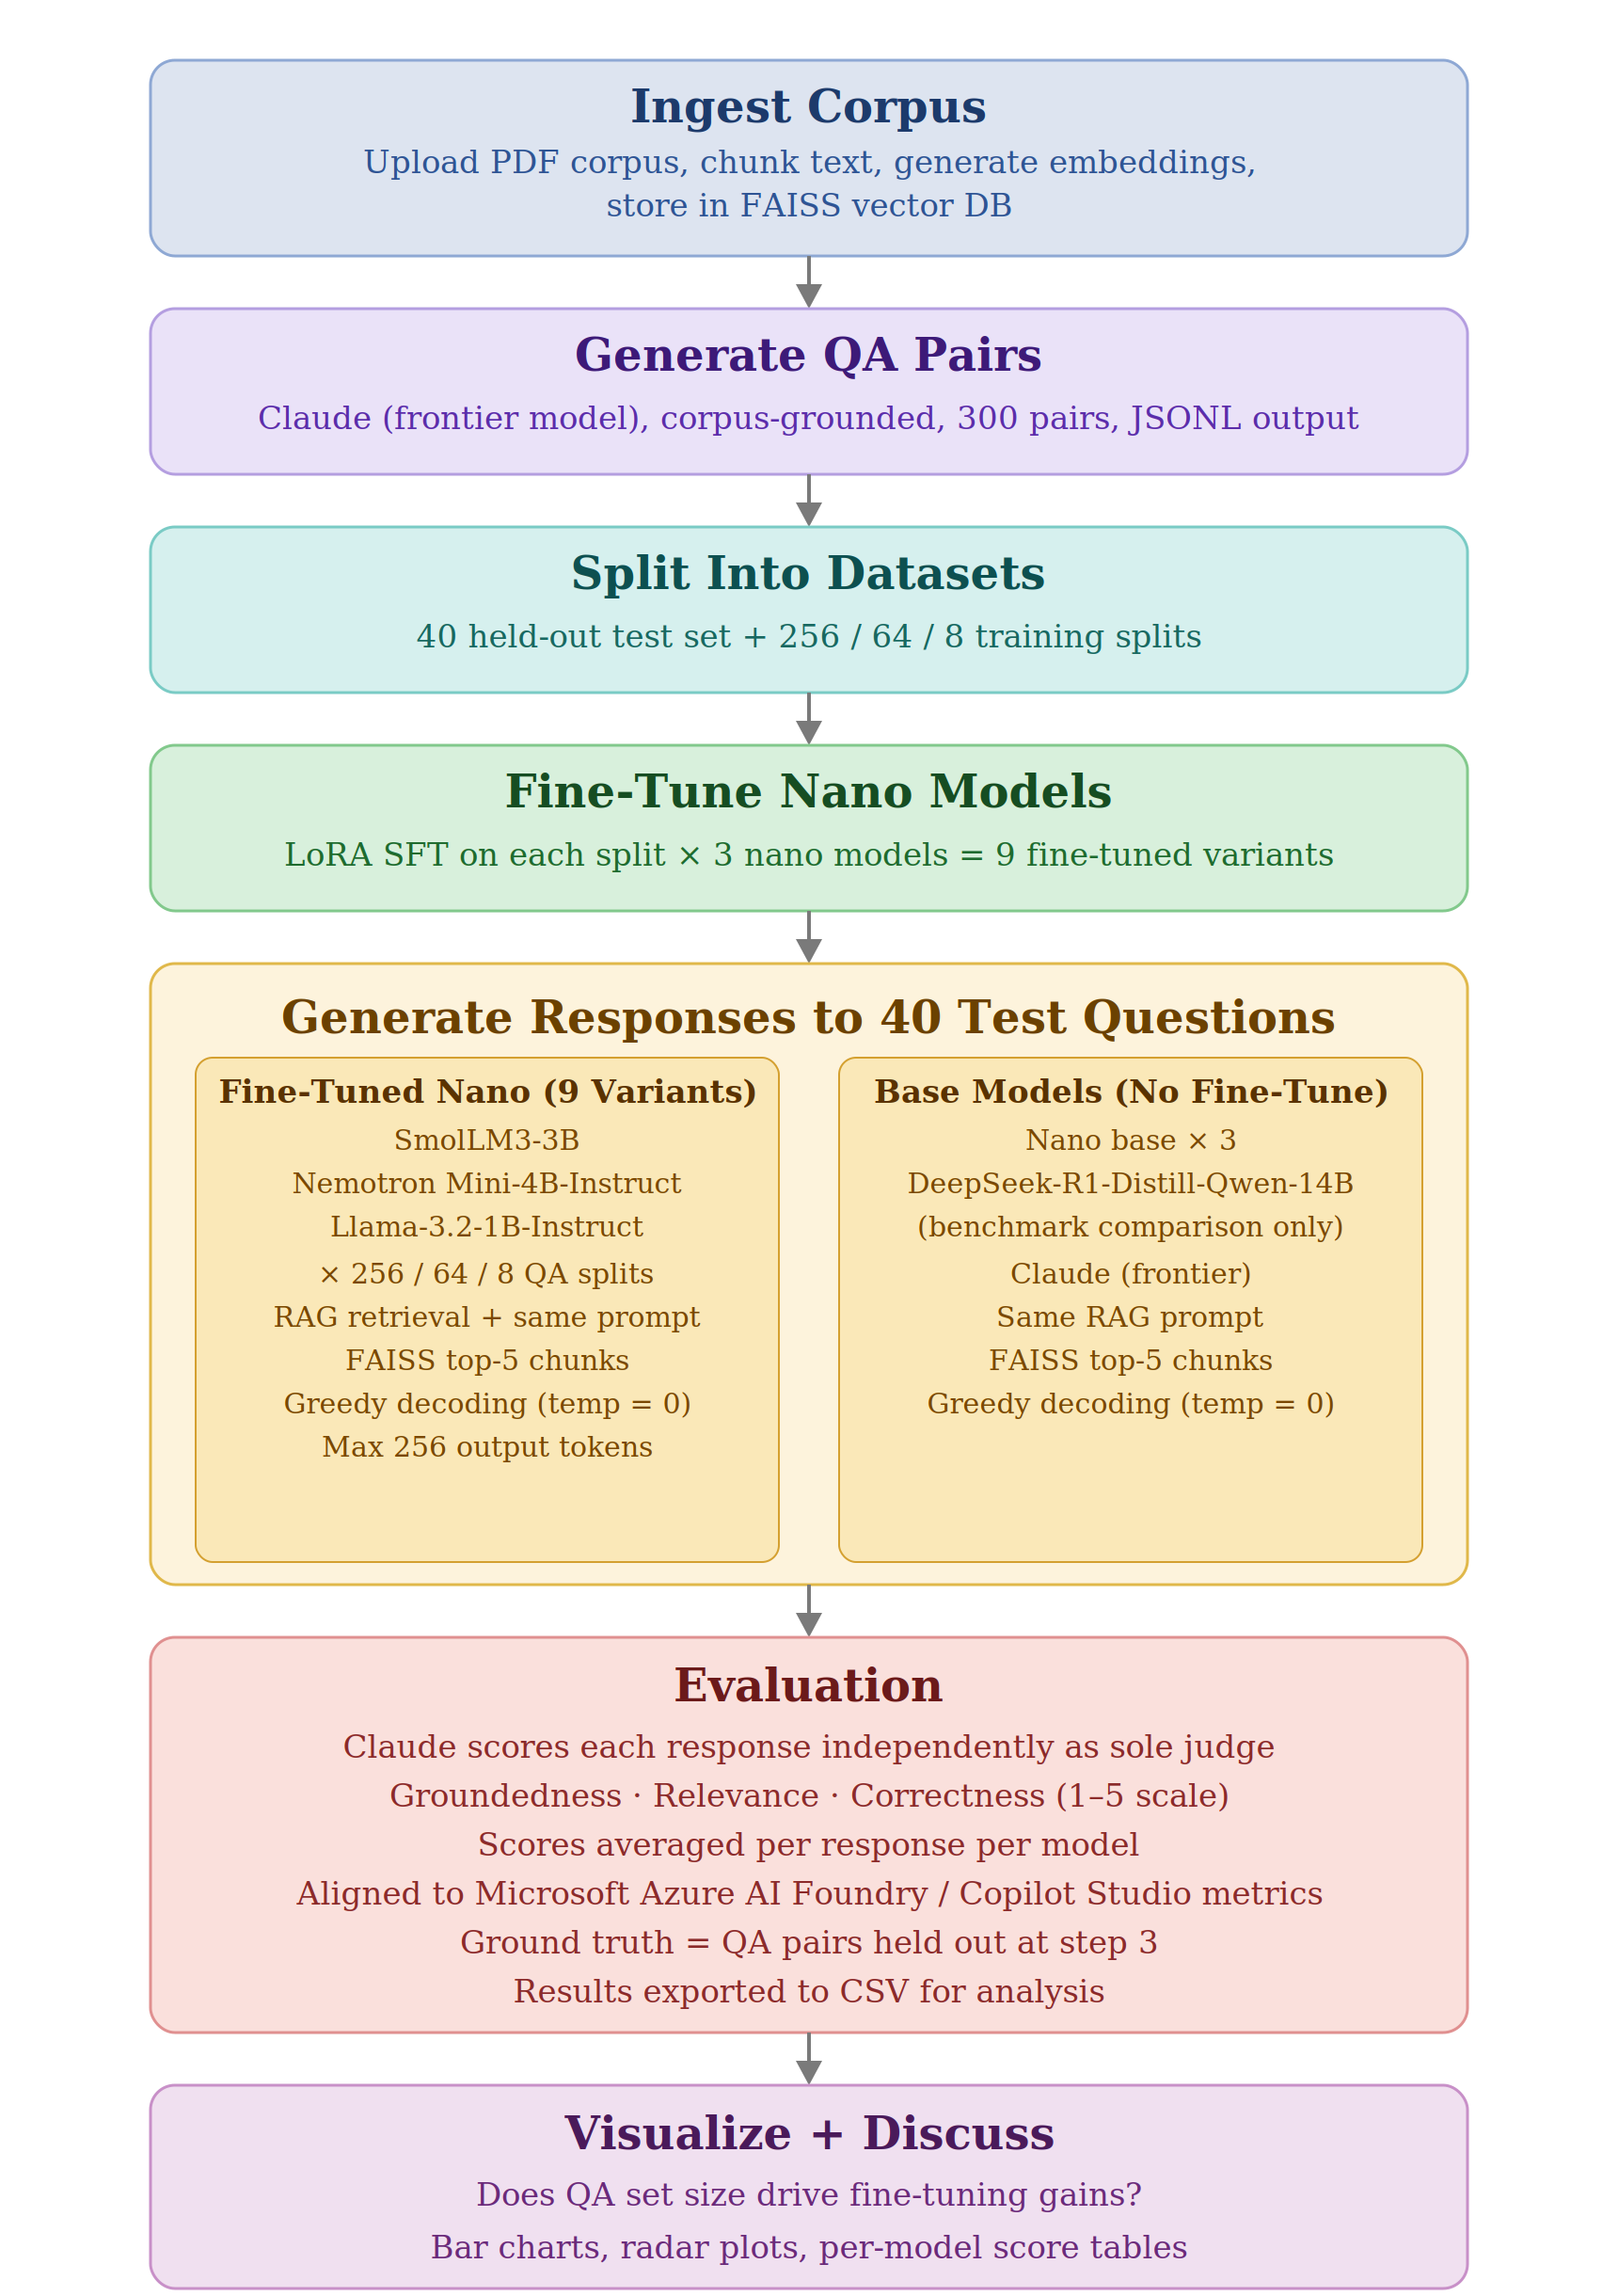



---



# 1. Import Libraries

**NOTE:** If using Google CoLab, connect to GPU with High Ram. May require subscription.

In [ ]:
# Install dependencies (run once)
!pip install transformers datasets huggingface_hub peft trl accelerate bitsandbytes
!pip install sentence-transformers faiss-cpu
!pip install anthropic
!pip install jsonlines tqdm
!pip install pypdf
!pip install matplotlib seaborn
!pip install -q -U google-generativeai
!pip install pdfplumber pymupdf
!pip install --upgrade transformers accelerate bitsandbytes optimum

In [ ]:
# Standard Library
import os
import json
import re
from pathlib import Path
import sklearn
from sklearn.model_selection import train_test_split
import pypdf
import random, time
from peft import PeftModel
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi
import pdfplumber
import fitz

# Third-party: data & numerics
import numpy as np
import pandas as pd
from tqdm import tqdm
import jsonlines
import gc
import hashlib
from typing import List, Dict
from sklearn.utils import resample

# PyTorch
import torch

# HuggingFace: models, tokenizers, datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
)
from datasets import Dataset, load_dataset
from huggingface_hub import login as hf_login

# HuggingFace: fine-tuning (PEFT / SFT)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

# Embeddings & vector store
from sentence_transformers import SentenceTransformer
import faiss

# Anthropic (Claude)
import anthropic

# Google CoLab
from google.colab import userdata

# Sanity check (print for check)
print(f"PyTorch version : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU name   : {torch.cuda.get_device_name(0)}")


import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*Both `max_new_tokens`.*and `max_length`.*"
)

# 2. Model Setup & API Connections

In [ ]:
# API Keys
HF_TOKEN      = userdata.get("HF_TOKEN")
ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_KEY")

# --- Reasoning Models (Baseline Inference) ---
REASONING_MODELS = {
    "deepseek" : "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B", # specifically high rank on RAG
}

# --- Nano Models (fine-tune targets) ---
NANO_MODELS = {
    "smollm"   : "HuggingFaceTB/SmolLM3-3B",
    "nemotron" : "nvidia/Nemotron-Mini-4B-Instruct",
    "llamaNano" : "meta-llama/Llama-3.2-1B-Instruct",
}

# LoRA target modules — override per model if architecture differs
LORA_TARGETS = {
    "smollm"   : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    "nemotron" : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    "llamaNano" : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
}

# --- Dataset sizes for SFT comparison ---
DATASET_SIZES = [256, 64, 32, 8]
NUM_TEST      = 40 # held-out questions (never used in training)

# --- Data Directories ---
DATASET_DIR   = Path("data") # filepath containing source PDFs
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Derived subdirectories — all cascade from DATASET_DIR
QA_DIR      = DATASET_DIR / "qa_outputs" # ./data/qa_outputs/
SPLITS_DIR  = DATASET_DIR / "qa_splits" # ./data/qa_splits/
MODELS_DIR  = DATASET_DIR / "models" # ./data/models/
RESULTS_DIR = DATASET_DIR / "results" # ./data/results/
EVAL_DIR    = DATASET_DIR / "eval" # ./data/eval/

# Create all directories
for d in [QA_DIR, SPLITS_DIR, MODELS_DIR, RESULTS_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"📁 Unified paths:")
print(f"  ROOT     : {DATASET_DIR}")
print(f"  QA       : {QA_DIR}")
print(f"  QA Splits: {SPLITS_DIR}")
print(f"  Models   : {MODELS_DIR}")
print(f"  Results  : {RESULTS_DIR}")
print(f"  Eval     : {EVAL_DIR}")

# --- API Connections ---
hf_login(token=HF_TOKEN)
print("\nHuggingFace login : OK")

# Claude
claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
CLAUDE_MODEL  = "claude-sonnet-4-6"
_ping = claude_client.messages.create(
    model=CLAUDE_MODEL, max_tokens=16,
    messages=[{"role": "user", "content": "Reply OK"}],
)
print(f"Claude connected  : {_ping.content[0].text.strip()}")

# --- Shared 4-bit quantization config ---
bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True,
    llm_int8_threshold=6.0,
)

# Define Random Seed
SEED = 7 # adjusted from 24 to 7 to 13 per Proffessor Anna Marbut's recommendation

print(f"\n RANDOM SEED = {SEED}")

print("\n✅ Config complete — models load on demand in later sections.")


# 3. Corpus Ingestion

Requires file(s) upload. Used key textbook for AAI Program as example.

Citation Needed:

In [ ]:
# Config
CHUNK_SIZE    = 384 # scaled down from 512 to reduce noise in chunks
CHUNK_OVERLAP = 96 # overlapping char number, to preserve context


# Load chunks if already exist, don't duplicate below if able
def load_corpus_chunks(chunks_path: Path):
    if chunks_path.exists():
        with jsonlines.open(chunks_path) as f:
            chunks = list(f)
        print(f"✅ Loaded {len(chunks):,} saved chunks from {chunks_path}")
        return chunks
    return None

# --- PDF Text Extraction ---

# Use PDF Plumber for more robust text extraction, fail to fitz if pdfplumber fails
# *Returns* concatonated text with page markers
def extract_text_from_pdf(pdf_path: Path) -> str:
    text_parts = []
    try:
        with pdfplumber.open(str(pdf_path)) as pdf:
            num_pages = len(pdf.pages)
            print(f"  Extracting {pdf_path.name} ({num_pages:,} pages)...")
            for i, page in enumerate(pdf.pages):
                page_text = page.extract_text() or ""
                if page_text.strip():
                    text_parts.append(f"--- Page {i+1} ---\n{page_text}")
                page.flush_cache()
                if (i + 1) % 100 == 0:
                    print(f"    Page {i+1}/{num_pages}")
            full_text = "\n\n".join(text_parts)
            print(f"  {pdf_path.name}: {num_pages:,} pages → {len(full_text):,} chars")
            return full_text
    except Exception as e:
        print(f"  pdfplumber failed: {e}")

    # Secondary fallback to fitz (PyMuPDF)
    try:
        doc = fitz.open(str(pdf_path))
        num_pages = len(doc)
        print(f"  Falling back to PyMuPDF for {pdf_path.name} ({num_pages:,} pages)...")
        for i, page in enumerate(doc):
            page_text = page.get_text()
            if page_text.strip():
                text_parts.append(f"--- Page {i+1} ---\n{page_text}")
            if (i + 1) % 100 == 0:
                print(f"    Page {i+1}/{num_pages}")
        doc.close()
        full_text = "\n\n".join(text_parts)
        print(f"  {pdf_path.name}: {num_pages:,} pages → {len(full_text):,} chars")
        return full_text
    except Exception as e:
        print(f"  PyMuPDF failed: {e}")
        return f"[EXTRACTION FAILED: {pdf_path.name}]"


# --- Text Chunking ---

# Split extracted text into semantically cohesive chunks
# Handles paragraph boundaries, overlaps, and filters small chunks
def chunk_text(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> list[str]:
    paragraphs = re.split(r'\n\s*\n|\n#{1,3}\s', text)
    chunks = []

    # Split text using blank lines or headers as separators
    for para in paragraphs:
        para = para.strip()
        if not para:
            continue

        # If paragraph fits chunk size, keep as-is
        if len(para) <= chunk_size:
            chunks.append(para)
        else:
            # Otherwise, split with overlaping windoes to maintain semantic continuity
            start = 0
            while start < len(para):
                chunk = para[start:start + chunk_size].strip()
                if chunk:
                    chunks.append(chunk)
                start += chunk_size - overlap

    # Filter out very short fragments (they are likely noise)
    return [c for c in chunks if len(c) > 50]


# --- Corpus Assembly ---
chunks_file = DATASET_DIR / "corpus_chunks.jsonl"
corpus_chunks = load_corpus_chunks(chunks_file)

if corpus_chunks is None:

    # Locate PDF Files
    pdf_files = sorted(DATASET_DIR.glob("*.pdf"))
    assert pdf_files, f"No PDFs found in {DATASET_DIR.resolve()}"

    corpus_chunks = []

    # Extract and chunk each PDF
    for pdf_path in pdf_files:
        raw_text = extract_text_from_pdf(pdf_path)
        chunks = chunk_text(raw_text)
        for i, chunk in enumerate(chunks):
            corpus_chunks.append({
                "source": pdf_path.name,
                "chunk_id": i,
                "text": chunk
            })
        print(f"  → {len(chunks):,} chunks from {pdf_path.name}")

    # Save all generated chunks to disk
    with jsonlines.open(chunks_file, "w") as f:
        f.write_all(corpus_chunks)
    print(f"\n\n\n💾 Saved {len(corpus_chunks):,} chunks to {chunks_file}")


# --- Corpus Statistics ---

# Count tokens for overview of chunk size distribution
_count_tok = AutoTokenizer.from_pretrained(list(NANO_MODELS.values())[0], token=HF_TOKEN)
total_tokens = 0
total_chars = 0
for chunk in corpus_chunks:
    total_chars += len(chunk["text"])
    total_tokens += len(_count_tok(chunk["text"], add_special_tokens=False)["input_ids"])
del _count_tok

print(f"  Avg chunk tokens: {total_tokens / len(corpus_chunks):.0f}")

# Preview a few randomly sampled chunks for sanity check
samples = random.sample(corpus_chunks, min(5, len(corpus_chunks)))
print("\n\n\n=== 5 RANDOM CHUNK SAMPLES ===")
for i, chunk in enumerate(samples, 1):
    print(f"\n{i}. {chunk['source']} (chunk {chunk['chunk_id']})")
    print(f"   {repr(chunk['text'][:200])}...")

# Display overall corpus statistics
print(f"\n=== CORPUS SUMMARY ===")
print(f"  PDFs loaded   : {len(set(c['source'] for c in corpus_chunks))}")
print(f"  Total chunks  : {len(corpus_chunks):,}")
print(f"  Total chars   : {total_chars:,}")
print(f"  Total tokens  : {total_tokens:,}")

# 4. Embeddings & Vector Store

Retrieval setup, turning pre-chunked corpus into a searchable knowledge base using sentence embeddings and FAISS, Facebook AI Similarity Search for effecient similarity searching.

In [ ]:
# Config
EMBED_MODEL_ID = "all-MiniLM-L6-v2"   # fast, reliable; can swap for larger model if needed, creates 384-dimensional embeddigns
TOP_K          = 5                     # default chunks to retrieve per query

# --- Model Loading ---
# Load embedding model, SentenceTransformer, maps text chunks or queries into dense vector embeddings
print(f"Loading embedding model: {EMBED_MODEL_ID} ...")
embed_model = SentenceTransformer(EMBED_MODEL_ID)
# Obtain model's embedding dimensionality to configure FAISS later
EMBED_DIM   = embed_model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {EMBED_DIM}")

# --- Encoding Corpus ---

# Extract raw text of all chunks into a simple list
print(f"Encoding {len(corpus_chunks):,} chunks ...")
chunk_texts = [c["text"] for c in corpus_chunks]

# Compute embeddings for each chunk in batches of 64
# normalize embeddings=True ensures embeddings have unit length for dot product later
chunk_embeddings = embed_model.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True, # required for cosine similarity via inner product
    convert_to_numpy=True,  # FAISS expects NumPy arrays
)

# --- FAISS Index Building ---

# Build FAISS index (cosine similarity via inner product on normalized vecs)
faiss_index = faiss.IndexFlatIP(EMBED_DIM)

# Store all embeddings into the index for retrieval
faiss_index.add(chunk_embeddings)
print(f"FAISS index built: {faiss_index.ntotal:,} vectors")

# --- Retrieval Function ---
# Retrieve top-k most semantically relavant chunks for a given text query
# *Return* Top-k chunks with original metadat and similarity score
def retrieve(query: str, k: int = TOP_K) -> list[dict]:

    # Encode query into same embedding sapce
    query_vec = embed_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
    )

    # Perform similarity search: returns (scores, indices)
    scores, indices = faiss_index.search(query_vec, k)
    results = []

    # Gather metadata
    for score, idx in zip(scores[0], indices[0]):
        results.append({**corpus_chunks[idx], "score": float(score)})
    return results

# --- Smoke Test ---
# Simple question to see how well it worked
test_query   = "What is artificial intelligence?"
test_results = retrieve(test_query)

print ("\n\n\n=== SMOKE TEST ===")
print(f"\nSmoke test — query: '{test_query}'")
for r in test_results:
    print(f"  [{r['score']:.3f}] {r['source']} chunk {r['chunk_id']}: {r['text'][:80]}...")


# 5. QA Pair Generation & Organization


In [ ]:
# Output File Path
combined_file = QA_DIR / "qa_claude_only.jsonl"

# Hyperparams
TARGET_QA = 300
SAMPLE_CHUNK_SIZE = 200  # how many chunks to sample per batch
BATCH_SIZE = 8           # how many calls per loop
MAX_NEW_TOKENS = 192
TEMPERATURE = 0.1
DEBUG_RAW = False

In [ ]:
# Deterministic Random Number generator
def get_rng(seed: int, offset: int = 0) -> random.Random:
    """Stable per‑run, deterministic RNG."""
    return random.Random(seed + offset)

# Extract a structured QA JSON object
def extract_json(text: str) -> dict | None:
    patterns = [
        r'\{.*?"question".*?"answer".*?\}',
        r'\{[^{}]*\}',
    ]
    for pattern in patterns:
        for m in re.findall(pattern, text, re.DOTALL):
            try:
                parsed = json.loads(m)
                if (
                    isinstance(parsed, dict)
                    and isinstance(parsed.get("question"), str)
                    and isinstance(parsed.get("answer"), str)
                    and parsed["question"].strip()
                    and parsed["answer"].strip()
                ):
                    return {
                        "question": parsed["question"].strip(),
                        "answer": parsed["answer"].strip(),
                    }
            except json.JSONDecodeError:
                continue
    # If no pattern yields valid QA, return None.
    return None

In [ ]:
# Generate one QA pair per passage using claude
def generate_qa_batch_claude(
    batch: List[Dict],
) -> List[Dict]:
    QA_PROMPT = """\
Generate EXACTLY ONE question-answer pair as valid JSON.
Return exactly:
{{"question": "Your question?", "answer": "Your answer from passage only"}}

Use only the passage below.

PASSAGE:
{passage}
"""

    new_rows = []

    for p in batch:
        # Extract and clean the passage text, strip leading trailing whitespace
        passage = p["text"].strip()
        # Format the QA prompt with the current passage
        prompt = QA_PROMPT.format(passage=p["text"].strip())

        if DEBUG_RAW:
            print(f"[DEBUG CLAUDE PROMPT] {repr(prompt[:300])}")


        # Call the Claude API with:
        # - model name defined in CLAUDE_MODEL
        # - token limit MAX_NEW_TOKENS
        # - fixed temperature for consistent generation
        # - a single user message containing the QA prompt
        msg = claude_client.messages.create(
            model=CLAUDE_MODEL,
            max_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            messages=[{"role": "user", "content": prompt}],
        )

        raw = "".join(
            block.text for block in msg.content
            if getattr(block, "type", None) == "text"
        ).strip()

        # Print full prompt for debugging, truncated to 300 chars
        if DEBUG_RAW:
            print(f"[DEBUG CLAUDE RAW] {repr(raw[:300])}")

        qa = extract_json(raw)

        if qa:
            new_rows.append({
                "id": len(new_rows),
                "question": qa["question"],
                "answer": qa["answer"],
                "source": p.get("source", "unknown"),
                "chunk_id": p["chunk_id"],
                "source_text": p["text"],
                "generator": "claude",
            })

        # Gentle rate‑limiting
        time.sleep(0.15)

    return new_rows

In [ ]:
# Check existing file, then load passages
PASSAGES_JSONL = Path("data/corpus_chunks.jsonl")

def load_jsonl(path: Path) -> List[Dict]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

if not PASSAGES_JSONL.exists():
    raise FileNotFoundError(
        f"Passages file not found at {PASSAGES_JSONL.resolve()}\n"
        f"Current dir: {os.getcwd()}\n"
        f"Files present: {os.listdir('.')}"
    )

passages = load_jsonl(PASSAGES_JSONL)

In [ ]:
# Function to run generation until target is hit
def generate_until_target_claude(
    passages: List[Dict],
    target: int = 300,
    batch_size: int = 8,
) -> List[Dict]:
    rng = get_rng(SEED, offset=100)  # stable across runs
    pool = list(passages)           # copy
    rng.shuffle(pool)               # reproducible shuffle

    qa_pairs = []
    cursor = 0

    with tqdm(total=target, desc="Claude QA gen") as pbar:
        while len(qa_pairs) < target and cursor < len(pool):
            # Sample a batch from pool
            n = min(batch_size, target - len(qa_pairs))
            batch = pool[cursor:cursor + n]
            cursor += n

            rows = generate_qa_batch_claude(batch)
            qa_pairs.extend(rows)

            pbar.n = min(len(qa_pairs), target)
            pbar.refresh()

            if len(qa_pairs) >= target:
                break

    print(f"Generated {len(qa_pairs)} QA pairs (target: {target})")
    return qa_pairs[:target]

In [ ]:
# --- Dry Run ---
# Use to ensure functioning as expected before larger token run
OUTPUT_FILE = QA_DIR / "qa_claude_300.jsonl"  # keep the same path


if OUTPUT_FILE.exists():
    print(f"Loading cached QA from {OUTPUT_FILE}")
    all_qa = load_jsonl(OUTPUT_FILE)
else:
    print("DRY‑RUN: Generating 5 QA pairs with Claude (no HF models)...")
    all_qa = generate_until_target_claude(passages, target=5, batch_size=BATCH_SIZE)

    # Append global IDs if you want
    for i, row in enumerate(all_qa):
        row["global_id"] = i

    print(f"DRY‑RUN output: {len(all_qa):,} QA pairs")
    print("Preview:")
    for row in all_qa:
        print(f"  Q: {row['question'][:80]}...")
        print(f"  A: {row['answer'][:80]}...")

    # Optional: don’t write to disk yet
    # print("Skipping disk write; rerun with target=300 when ready.")

In [ ]:
# --- EXECUTION: Generate 300 QA from Claude ---

OUTPUT_FILE = QA_DIR / "qa_claude_300.jsonl"

if OUTPUT_FILE.exists():
    print(f"Loading cached QA from {OUTPUT_FILE}")
    all_qa = load_jsonl(OUTPUT_FILE)
else:
    print("Generating 300 QA pairs with Claude (no HF models)...")
    all_qa = generate_until_target_claude(passages, target=300, batch_size=BATCH_SIZE)

    # Append global IDs
    for i, row in enumerate(all_qa):
        row["global_id"] = i

    print(f"Saving {len(all_qa):,} QA pairs to {OUTPUT_FILE}")
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        for row in all_qa:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

# Create QA Subsets

Question/Answer Subsets

- Create Four QA subsets of different sizes (256, 64, 8), and test set of 40

In [ ]:
# Config Dataset Splitting
# Creates four sized training splits (256 / 64 / 8) and the 40-question
# held-out test set. All written to disk — re-run without regenerating QA.

# Load combined QA from disk if not already in memory
if "all_qa_pairs" not in dir() or not all_qa_pairs:
    with jsonlines.open(QA_DIR / "qa_claude_300.jsonl") as reader:
        all_qa_pairs = list(reader)
    print(f"Loaded {len(all_qa_pairs)} QA pairs from disk.")
    # Use Claude‑only QA instead of mixed HF+Claude
    with jsonlines.open(QA_DIR / "qa_claude_300.jsonl") as reader:
        all_qa_pairs = list(reader)
    print(f"Loaded {len(all_qa_pairs)} Claude‑only QA pairs from disk.")

random.seed(SEED)
shuffled   = all_qa_pairs.copy()
random.shuffle(shuffled)

# Reserve NUM_TEST for held-out test set
test_pairs = shuffled[:NUM_TEST]
train_pool = shuffled[NUM_TEST:]  # 300 available from generation

# Save test set
test_file = SPLITS_DIR / "test_40.jsonl"
with jsonlines.open(test_file, mode="w") as writer:
    writer.write_all(test_pairs)
print(f"Test set  ({len(test_pairs):>3} questions) → {test_file}")

# Create and save each training split
train_splits = {}
for size in DATASET_SIZES:
    n      = min(size, len(train_pool))
    subset = train_pool[:n]
    train_splits[size] = subset
    split_file = SPLITS_DIR / f"train_{size}.jsonl"
    with jsonlines.open(split_file, mode="w") as writer:
        writer.write_all(subset)
    print(f"  Train [{size:>3}q] → {split_file}  ({len(subset)} pairs)")

print(f"\n✅ All splits saved to {SPLITS_DIR}")
print(f"   Training sizes: {[len(v) for v in train_splits.values()]} | Test: {len(test_pairs)}")


# 7. Training: Supervised Fine-Tuning (LoRA + SFT)

LoRA, Low-Rank Adaptation, is a technique where all pre-trained weights are frozen and a subset of trainable paramters are injected into the architecture and then trained on specific example sets.

- Fine-tunes every nano model on every dataset size: 3 models × 3 sizes = 9 runs.
- Completed runs are skipped unless FORCE_RETRAIN=True.
- Each fine-tuned model saved to: models/{nano_key}_ft_{size}q/

In [ ]:
# Config

FORCE_RETRAIN = False

# --- LoRA hyperparameters ---
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.15 # increased from .5 to address overfitting on QA artifacts for larger dataset

# --- Training hyperparameters ---
NUM_EPOCHS    = 3
BATCH_SIZE    = 4
GRAD_ACCUM    = 4        # effective batch size = 16
LEARNING_RATE = 2e-4
MAX_SEQ_LEN   = 512
TRAIN_SPLIT   = 0.9

# --- Load splits from disk ---
QA_DIR     = DATASET_DIR / "qa_outputs"
SPLITS_DIR = DATASET_DIR / "qa_splits"


# load immutable 40 questoin test set
with jsonlines.open(SPLITS_DIR / "test_40.jsonl") as r:
    test_pairs = list(r)

# Load each training split into memory
train_splits = {}
for size in DATASET_SIZES:
    with jsonlines.open(SPLITS_DIR / f"train_{size}.jsonl") as r:
        train_splits[size] = list(r)

# Print dataset overview
print(f"Test set  : {len(test_pairs)} questions")
for size, pairs in train_splits.items():
    print(f"  Train [{size:>3}q]: {len(pairs)} pairs")

# --- Chat Formatter ---
# Convert single QA pair chat formatted training text
def format_chat(pair: dict, tokenizer) -> str:
    messages = [
        {"role": "user",      "content": pair["question"]},
        {"role": "assistant", "content": pair["answer"]},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False,
    )

# --- Core SFT Function ---
# Fine tune one nano model on on dataset size
# Flow: load, format, LoRA, train, save, cleanup
def run_sft(nano_key: str, nano_id: str, size: int, pairs: list[dict]) -> Path:

    # Deterministic output dir
    out_dir = MODELS_DIR / f"{nano_key}_ft_{size}q"

    # Cache check, if file exists
    if out_dir.exists() and not FORCE_RETRAIN:
        print(f"Skipping {nano_key} × {size}q — checkpoint exists at {out_dir}")
        return out_dir

    print(f"\n{'─'*60}")
    print(f"  Fine-tuning : {nano_key} | dataset size : {size}q")
    print(f"  Model ID    : {nano_id}")
    print(f"{'─'*60}")

    # Load base model + tokenizer
    tok = AutoTokenizer.from_pretrained(nano_id, token=HF_TOKEN)
    tok.pad_token = tok.eos_token # required for batching

    base_model = AutoModelForCausalLM.from_pretrained(
        nano_id,
        torch_dtype=torch.bfloat16, # more effecient
        device_map="auto", # GPU/CPU auto-placement
        token=HF_TOKEN,
    )

    # --- Format & Split ---
    texts = [format_chat(p, tok) for p in pairs]
    train_texts, val_texts = train_test_split(
        texts, train_size=TRAIN_SPLIT, random_state=SEED
    )
    train_ds = Dataset.from_dict({"text": train_texts})
    val_ds   = Dataset.from_dict({"text": val_texts})

    # --- LoRA Config ---
    lora_cfg = LoraConfig(
        r=LORA_R, # Rank
        lora_alpha=LORA_ALPHA, # Scaling
        lora_dropout=LORA_DROPOUT, # Regularization
        target_modules=LORA_TARGETS[nano_key], # Model-specific
        task_type=TaskType.CAUSAL_LM, bias="none", # Don't train bias terms
    )
    ft_model = get_peft_model(base_model, lora_cfg)
    ft_model.print_trainable_parameters()

    # --- Training Config ---
    sft_cfg = SFTConfig(
        output_dir=str(out_dir),
        logging_dir=str(MODELS_DIR / "logs"),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM, # effective batch size
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=True, # precision
        max_length=MAX_SEQ_LEN, # truncate long sequences
        dataset_text_field="text", # Uses formatted texts
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        report_to="none",
    )

    # --- Train ---
    trainer = SFTTrainer(
        model=ft_model,
        args=sft_cfg,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tok, # handles tokenization/padding
    )
    result = trainer.train()
    print(f"  Loss: {result.training_loss:.4f}  |  Runtime: {result.metrics['train_runtime']:.0f}s")

    # --- Save ---
    out_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(out_dir))
    tok.save_pretrained(str(out_dir))
    print(f"  Saved → {out_dir}")

    # --- GPU Cleanup ---
    # Unload before next run
    del ft_model, base_model, tok, trainer
    torch.cuda.empty_cache()
    return out_dir


# --- Main Training Loop: # nano models × # dataset sizes ---
total_runs   = len(NANO_MODELS) * len(DATASET_SIZES)
run_num      = 0
ft_model_dirs = {}  # {nano_key: {size: Path}}

print(f"\n\n\nStarting {total_runs} fine-tuning runs...")
print(f"   Models: {list(NANO_MODELS.keys())}")
print(f"   Sizes : {DATASET_SIZES}")

for nano_key, nano_id in NANO_MODELS.items():
    ft_model_dirs[nano_key] = {}
    for size in DATASET_SIZES:
        run_num += 1
        print(f"\n[Run {run_num}/{total_runs}]  {nano_key}  ×  {size}q")
        ft_dir = run_sft(nano_key, nano_id, size, train_splits[size])
        ft_model_dirs[nano_key][size] = ft_dir

print(f"\n✅ SFT complete — {total_runs} runs ({len(NANO_MODELS)} models × {len(DATASET_SIZES)} sizes)")
for nano_key, sizes in ft_model_dirs.items():
    for size, path in sizes.items():
        print(f"  {nano_key}_ft_{size}q → {path}")


# 8. RAG Inference - Base + Fine-Tuned

- Runs 40 held-out questions through every model: 3 base nano, 9 fine-tuned nano, and four larger models and Claude as frontier model.
- Results saved per-model to data/results/ — skips cached files unless FORCE_REINFER=True.

Full RAG pipeline for one question:

    1. Retrieve top-k chunks from FAISS index
    2. Build context-augmented prompt
    3. Generate answer with HF model

In [ ]:
# Config

FORCE_REINFER   = False # skip cached results?
RAG_MAX_TOKENS  = 256 # max output length per answer
RAG_TEMPERATURE = 0.0 # sampling (0.0 = greedy, 1.0 = creative), 0 for comparability

RAG_PROMPT = """\
You are a helpful assistant. Answer the question using ONLY the context provided.
If the context does not contain enough information, say so.

Context:
{context}

Question: {question}
Answer:"""

# --- Load test pairs from disk ---
# *Returns* (generated_answer, retrieved_chunks_list)
SPLITS_DIR = DATASET_DIR / "qa_splits"

with jsonlines.open(SPLITS_DIR / "test_40.jsonl") as r:
    test_pairs = list(r)
print(f"Test set: {len(test_pairs)} questions")

# Retrieve context, build prompt, generate answer with a HuggingFace model.
def rag_answer_hf(question: str, model, tokenizer,
                  k: int = TOP_K) -> tuple[str, list[dict]]:
    chunks  = retrieve(question, k=k) # retrieve, FAISS cosine similarity
    context = "\n\n".join(c["text"] for c in chunks)
    prompt  = RAG_PROMPT.format(context=context, question=question) # build prompt

    # Toeknize + Generate
    inputs  = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=1024
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=RAG_MAX_TOKENS,
            temperature=RAG_TEMPERATURE, do_sample=RAG_TEMPERATURE > 0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Extract generated text
    new_ids = out[0][inputs["input_ids"].shape[-1]:]
    answer  = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return answer, chunks


# Full Model Evaluation

# Load a HuggingFace model, run all test questions, save results.
# Pass ft_dir to load as a PEFT adapter on top of model_id (fine-tuned).
# Model is unloaded after inference to free VRAM.
def run_hf_inference(model_label: str, model_id: str,
                     ft_dir: Path | None = None) -> list[dict]:

    out_file = RESULTS_DIR / f"{model_label}.jsonl"
    if out_file.exists() and not FORCE_REINFER:
        print(f"Cached: {out_file}")
        with jsonlines.open(out_file) as r:
            return list(r)

    suffix = f" + LoRA {ft_dir.name}" if ft_dir else " (base)"
    print(f"\n  Loading {model_id}{suffix}")

    # Load Tokenizer — prefer ft_dir so chat template matches fine-tuned model
    tok = AutoTokenizer.from_pretrained(
        str(ft_dir) if ft_dir else model_id, token=HF_TOKEN
    )
    tok.pad_token = tok.eos_token

    # Load Model
    base = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16, # memory effecient
        device_map="auto", # multi-GPU if available
        token=HF_TOKEN,
    )
    mdl = PeftModel.from_pretrained(base, str(ft_dir)) if ft_dir else base
    mdl.eval()

    # Evaluate results
    results = []
    for pair in tqdm(test_pairs, desc=model_label):
        answer, chunks = rag_answer_hf(pair["question"], mdl, tok)
        results.append({
            "id"              : pair["id"], # unique question ID
            "question"        : pair["question"],
            "ground_truth"    : pair["answer"],
            "source"          : pair["source"], # original PDF chunk
            "answer"          : answer, # model RAG answer
            "model_label"     : model_label,
            "retrieved_chunks": [c["chunk_id"] for c in chunks], # traceability
        })

    # Save
    with jsonlines.open(out_file, mode="w") as writer:
        writer.write_all(results)
    print(f"  Saved {len(results)} results → {out_file}")

    # GPU Cleanup
    del mdl, base, tok
    torch.cuda.empty_cache()
    return results


# --- Retrieval with Claude ---

# Claude RAG inference:
#   1. Retrieve top-k chunks from FAISS
#   2. Build the same RAG prompt used for HF models
#   3. Send prompt to Claude via Anthropic Messages API

def rag_answer_claude(question: str, k: int = TOP_K) -> tuple[str, list[dict]]:
    chunks = retrieve(question, k=k)
    context = "\n\n".join(c["text"] for c in chunks)
    prompt = RAG_PROMPT.format(context=context, question=question)

    msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=RAG_MAX_TOKENS,
        temperature=RAG_TEMPERATURE,
        messages=[{"role": "user", "content": prompt}],
    )

    # Handle answer with robust version
    answer = "".join(
        block.text for block in msg.content
        if getattr(block, "type", None) == "text"
    ).strip()

    return answer, chunks

# --- Inference with Claude ---
def run_claude_inference(model_label: str = "frontier_claude") -> list[dict]:
    """
    Run Claude on all 40 held-out test questions using the same RAG pipeline
    as the Hugging Face models, then save results to disk.

    Uses the globally initialized claude_client and CLAUDE_MODEL.
    """
    out_file = RESULTS_DIR / f"{model_label}.jsonl"

    # Fast path: reuse cached inference results unless forcing regeneration
    if out_file.exists() and not FORCE_REINFER:
        print(f"Cached: {out_file}")
        with jsonlines.open(out_file) as r:
            return list(r)

    print(f"\n  Loading {CLAUDE_MODEL} (FRONTIER MODEL)")

    results = []
    for pair in tqdm(test_pairs, desc=model_label):
        answer, chunks = rag_answer_claude(pair["question"])
        results.append({
            "id": pair["id"],
            "question": pair["question"],
            "ground_truth": pair["answer"],
            "source": pair["source"],
            "answer": answer,
            "model_label": model_label,
            "retrieved_chunks": [c["chunk_id"] for c in chunks],
        })

    with jsonlines.open(out_file, mode="w") as writer:
        writer.write_all(results)

    print(f"  Saved {len(results)} results → {out_file}")
    return results


# --- Reload ft_model_dirs from disk if not in memory ---
SPLITS_DIR = QA_DIR / "splits"
ft_model_dirs = {}
for nano_key in NANO_MODELS:
    ft_model_dirs[nano_key] = {}
    for size in DATASET_SIZES:
        ft_model_dirs[nano_key][size] = MODELS_DIR / f"{nano_key}_ft_{size}q"

all_inference_results = {} # {model_label, results_list}


# --- MAIN EVALUATION ---

# --- Base Nano Models ---
print("\n=== NANO BASE MODELS ===")
for nano_key, nano_id in NANO_MODELS.items():
    label = f"{nano_key}_base"
    all_inference_results[label] = run_hf_inference(label, nano_id)

# --- Fine-tuned nano models (3 × 4 = 12) ---
print("\n=== NANO FINE-TUNED MODELS ===")
for nano_key, nano_id in NANO_MODELS.items():
    for size in DATASET_SIZES:
        label  = f"{nano_key}_ft_{size}q"
        ft_dir = ft_model_dirs[nano_key][size]
        all_inference_results[label] = run_hf_inference(label, nano_id, ft_dir=ft_dir)

# --- Reasoning model baselines — RAG with larger models ---
print("\n=== REASONING MODELS ===")
for rm_key, rm_id in REASONING_MODELS.items():
    label = f"reasoning_{rm_key}"
    all_inference_results[label] = run_hf_inference(label, rm_id)

# --- Frontier model baseline — RAG with Claude ---
print("\n=== FRONTIER MODEL (Claude 4.6 Sonnet) ===")
all_inference_results["frontier_claude"] = run_claude_inference()

print(f"\n✅✅✅ Inference complete — {len(all_inference_results)} model variants")
for label in all_inference_results:
    print(f"  {label}")


# 8. Evaluation - Groundedness, Relavance, Response Completeness

- Scores each answer on groundedness, relevance, completeness (1–5).


Metric definitions align with Microsoft Azure AI Foundry / Copilot Studio: https://learn.microsoft.com/en-us/azure/foundry/concepts/evaluation-evaluators/rag-evaluators

**Groundedness**  (1–5): Is the response supported by the retrieved context?
   - 1 = Ungrounded / contradicts context
   - 3 = Partially grounded, some unsupported claims
   - 5 = Fully grounded, every claim traceable to context

**Relevance**     (1–5): Does the response directly address the question?
   - 1 = Off-topic or unrelated
   - 3 = Partially addresses the question
   - 5 = Completely and precisely answers the question

 **Response Completeness**   (1–5): Does the response cover all critical information from ground truth?
   - 1 = Factually wrong or contradicts ground truth or omits almost all key information
   - 3 = Partially correct, missing key facts
   - 5 = Fully correct, consistent with ground truth, covers all essential facts in a coherent way

In [ ]:
# Config

FORCE_REEVAL = False # skip cached results?
METRICS      = ["groundedness", "relevance", "completeness"] # 1-5 scale

EVAL_PROMPT = """
You are an expert evaluator for AI-generated responses, following Microsoft Azure AI Foundry evaluation standards.

Score the RESPONSE on three dimensions (each 1–5):

groundedness: Is every claim in the response supported by the CONTEXT?
  1=Ungrounded  2=Mostly unsupported  3=Partially grounded  4=Mostly grounded  5=Fully grounded

relevance: Does the response directly and completely address the QUESTION?
  1=Off-topic  2=Tangentially related  3=Partially addresses  4=Mostly relevant  5=Fully relevant

completeness: How well does the response match the GROUND TRUTH answer in terms of Response Completeness (coverage of critical information)?
  1=Factually wrong, Contradicts  2=Mostly wrong  3=Partially correct, missing key facts  4=Mostly correct, only minor omissions  5=Fully correct, covers all essential facts in a coherent way

Respond in valid JSON only:
{{"groundedness": <1-5>, "relevance": <1-5>, "completeness": <1-5>, "reason": "<one concise sentence>"}}

CONTEXT:
{context}

QUESTION:
{question}

GROUND TRUTH:
{ground_truth}

RESPONSE:
{response}
"""

# Single response evaluation
def evaluate_response(question, ground_truth, response, context) -> dict:
    prompt = EVAL_PROMPT.format(
        context=context[:1500], question=question,
        ground_truth=ground_truth, response=response,
    )

    # Call claude API
    msg = claude_client.messages.create(
        model=CLAUDE_MODEL, max_tokens=128,
        messages=[{"role": "user", "content": prompt}],
    )
    raw   = msg.content[0].text.strip()

    # Extract JSON scores using regex
    match = re.search(
        r'\{.*?"groundedness".*?"relevance".*?"completeness".*?\}',
        raw, re.DOTALL # . matches newlines
    )
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass # fall through to None scores

    # Fallback: parsing failed
    return {"groundedness": None, "relevance": None, "completeness": None, "reason": raw}


# Retrieve context for scoring
def get_context_str(question: str, k: int = TOP_K) -> str:
    return "\n\n".join(c["text"] for c in retrieve(question, k=k))


# Full Model Evaluation
#*Returns* results with added scores dict
def evaluate_model(model_label: str, results: list[dict]) -> list[dict]:
    """Score all 40 answers for one model variant."""
    eval_file = EVAL_DIR / f"{model_label}.jsonl"
    if eval_file.exists() and not FORCE_REEVAL:
        print(f"Cached: {eval_file}")
        with jsonlines.open(eval_file) as r:
            return list(r)

    scored = []
    for r in tqdm(results, desc=f"Eval [{model_label}]"):
        #Re-retrieve context for consistent scoring (same as inference)
        context = get_context_str(r["question"])

        # Get Claude Scores
        scores  = evaluate_response(r["question"], r["ground_truth"], r["answer"], context)

        # Rate limit claude API safe
        time.sleep(0.15)
        scored.append({**r, **scores}) # merge original results + scores

    # cache scored results
    with jsonlines.open(eval_file, mode="w") as writer:
        writer.write_all(scored)
    print(f"  Saved → {eval_file}")
    return scored


# --- Load inference results from disk if not in memory ---
if "all_inference_results" not in dir() or not all_inference_results:
    all_inference_results = {}
    for f in sorted(RESULTS_DIR.glob("*.jsonl")):
        with jsonlines.open(f) as reader:
            all_inference_results[f.stem] = list(reader)
    print(f"Loaded inference results for {len(all_inference_results)} models from disk.")


In [ ]:
# --- Main Evaluation Loop (All Models) ---
all_eval_results = {}
labels = list(all_inference_results.keys())

print(f"\n\n\n🔎 Evaluating {len(labels)} model variants...")

for i, (model_label, results) in enumerate(all_inference_results.items()):
    print(f"\n[{i+1}/{len(labels)}] {model_label}")
    all_eval_results[model_label] = evaluate_model(model_label, results)

# --- Summary Table ---
rows = []
for label, scored in all_eval_results.items():
    df_m = pd.DataFrame(scored)
    row  = {"model": label}

    # Compute mean scores per metric
    for m in METRICS:
        row[m] = df_m[m].dropna().astype(float).mean()

    # Overall score = average of 3 metrics
    row["overall"] = pd.Series([row[m] for m in METRICS]).mean()
    rows.append(row)

# Create ranked summary table
summary_df = pd.DataFrame(rows).set_index("model").sort_values("overall", ascending=False)
summary_df.to_csv(Path("data/eval_summary.csv"))

print("\n=== EVALUATION SUMMARY (1–5, Microsoft Azure AI Foundry) ===")
print(summary_df.round(3).to_string())
print("\nSaved to data/eval_summary.csv")

#9. Results + Visualization

In [ ]:
# Config

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
METRICS = ["groundedness", "relevance", "completeness"]

# Load summary from disk if not in memory
if "summary_df" not in dir():
    summary_df = pd.read_csv("data/eval_summary.csv", index_col="model")

if "all_eval_results" not in dir() or not all_eval_results:
    all_eval_results = {}
    for f in sorted(EVAL_DIR.glob("*.jsonl")):
        with jsonlines.open(f) as reader:
            all_eval_results[f.stem] = list(reader)

sns.set_theme(style="whitegrid", font_scale=1.05)

def model_color(label):
    if "claude" in label:        return "#8bd3c7"
    if "reasoning" in label:     return "#b8d4f0"
    if "_ft_" in label:          return "#fd7f6f"
    return "#7eb0d5"  # base nano


# --- FIGURE 1: SFT dataset size effect per nano model ---
fig1, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True, sharey=True)
fig1.suptitle("SFT Impact: Overall Score vs Dataset Size per Nano Model",
              fontsize=13, fontweight="bold")


for ax, nano_key in zip(axes, NANO_MODELS.keys()):
    xs, ys = [0], []
    base_label = f"{nano_key}_base"
    base_score = summary_df.loc[base_label, "overall"] if base_label in summary_df.index else None
    if base_score is not None:
        ys.append(base_score)
    for size in sorted(DATASET_SIZES):
        ft_label = f"{nano_key}_ft_{size}q"
        if ft_label in summary_df.index:
            xs.append(size)
            ys.append(summary_df.loc[ft_label, "overall"])


    ax.plot(xs, ys, marker="o", linewidth=2, color="#fd7f6f", zorder=3)
    if base_score:
        ax.axhline(base_score, linestyle="--", color="#7eb0d5", linewidth=1.5, label="Base")
    ax.set_title(nano_key.upper(), loc="left", fontweight="bold")
    ax.set_ylabel("Overall Score (1–5)")
    ax.set_ylim(0, 5.5)
    ax.set_xticks(xs)
    ax.set_xticklabels(["Base"] + [str(s) for s in sorted(DATASET_SIZES)], fontsize=9)
    ax.legend(fontsize=8)


axes[-1].set_xlabel("Training QA pairs (0 = base)")
plt.tight_layout()
fig1.savefig(FIGURES_DIR / "fig1_sft_dataset_size.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR}/fig1_sft_dataset_size.png")


# --- FIGURE 2: Horizontal bar — all model variants ranked by overall score ---
fig2, ax = plt.subplots(figsize=(14, max(6, len(summary_df) * 0.38)))
sorted_df = summary_df.sort_values("overall", ascending=True)
colors    = [model_color(idx) for idx in sorted_df.index]
bars = ax.barh(sorted_df.index, sorted_df["overall"],
               color=colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, sorted_df["overall"]):
    ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("Overall Score (1–5)")
ax.set_title("All Model Variants — Overall Performance (ranked)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 5.9)
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#E74C31", label="Base nano"),
    Patch(color="#F39C11", label="Fine-tuned nano"),
    Patch(color="#3498C1", label="Reasoning model"),
    Patch(color="#8E44A1", label="Claude (frontier)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
fig2.savefig(FIGURES_DIR / "fig2_all_models_ranked.png", dpi=150, bbox_inches="tight")
plt.show()

# --- FIGURE 3: Heatmap — all models × 3 metrics ---
heat_data = summary_df[METRICS].sort_values("groundedness", ascending=False)
fig3, ax  = plt.subplots(figsize=(8, max(6, len(heat_data) * 0.38)))
im = ax.imshow(heat_data.values.astype(float), cmap="RdYlGn",
               aspect="auto", vmin=1, vmax=5)
ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([m.capitalize() for m in METRICS], fontsize=11)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=8)
for i in range(len(heat_data)):
    for j in range(len(METRICS)):
        v = heat_data.values[i, j]
        ax.text(j, i, f"{float(v):.2f}", ha="center", va="center", fontsize=8,
                color="black" if 2 < float(v) < 4.5 else "white")
plt.colorbar(im, ax=ax, label="Score (1–5)")
ax.set_title("Score Heatmap: All Models × Metrics", fontsize=12, fontweight="bold")
plt.tight_layout()
fig3.savefig(FIGURES_DIR / "fig3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# --- FIGURE 4: Average FT gain per nano model (bar) — dataset size on x-axis ---
fig4, ax = plt.subplots(figsize=(12, 5))
width = 0.25
x     = np.arange(len(DATASET_SIZES))
colors_nano = ["#E74C3C", "#F39C12", "#3498DB"] #Red, Orange, Blue

for i, nano_key in enumerate(NANO_MODELS.keys()):
    base_label = f"{nano_key}_base"
    base_s = summary_df.loc[base_label, "overall"] if base_label in summary_df.index else 0
    gains  = []
    for size in DATASET_SIZES:
        ft_label = f"{nano_key}_ft_{size}q"
        ft_s = summary_df.loc[ft_label, "overall"] if ft_label in summary_df.index else base_s
        gains.append(ft_s - base_s)
    ax.bar(x + i * width, gains, width=width, label=nano_key, color=colors_nano[i], edgecolor="white")

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels([f"{s}q" for s in DATASET_SIZES])
ax.set_xlabel("Training dataset size")
ax.set_ylabel("Overall score delta vs base")
ax.set_title("SFT Gain over Base per Nano Model", fontsize=12, fontweight="bold")
ax.legend(title="Nano model")
plt.tight_layout()
fig4.savefig(FIGURES_DIR / "fig4_sft_gain_per_model.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n\n\n 🛟All figures saved to {FIGURES_DIR}")


In [ ]:
# Meta data

#Export into a csv raw eval data (path)
EVAL_DIR = Path("data/eval")

# Collect all model files
all_eval_data = []

for model_file in EVAL_DIR.glob("*.jsonl"):
    model_name = model_file.stem  # e.g., "llamaNano_base", "nemotron_ft_256q"
    print(f"Loading {model_file.name}...")

    for line in open(model_file):
        try:
            row = json.loads(line.strip())
            row["model"] = model_name  # Add model column
            all_eval_data.append(row)
        except json.JSONDecodeError:
            continue  # Skip malformed lines

# Create unified DataFrame
df = pd.DataFrame(all_eval_data)
print(f"\n✅ Merged {len(df)} evaluation rows from {len(list(EVAL_DIR.glob('*.jsonl')))} models")

# Save full database
df.to_csv("data/full_eval_database.csv", index=False)
df.to_json("data/full_eval_database.jsonl", orient="records", lines=True)

print("Saved to:")
print("  - full_eval_database.csv")
print("  - full_eval_database.jsonl")

In [ ]:
# Compute overall (mean of 3 metrics)
df['overall'] = df[['groundedness', 'relevance', 'completeness']].mean(axis=1)

# Now rankings work
print("\nTop 5 models (overall):")
print(df.groupby('model')['overall'].mean().sort_values(ascending=False).head())

# Save updated database
df.to_csv("data/full_eval_database.csv", index=False)
print("✅ Added 'overall' column → saved")

In [ ]:
# Print overview
print("📊 FULL BREAKDOWN")
print("="*50)
print(f"Rows: {len(df):,}")
print(f"Models: {df['model'].nunique()}")
print(f"Questions: {df['question'].nunique()}")

# Per-metric rankings
metrics = ['groundedness', 'relevance', 'completeness', 'overall']
for metric in metrics:
    print(f"\n🏆 Top 3 {metric}:")
    print(df.groupby('model')[metric].mean().nlargest(3))

print("\n📈 Score distributions:")
print(df[['groundedness', 'relevance', 'completeness', 'overall']].describe())

In [ ]:
# Increase display width so long text is visible
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("📊 FULL BREAKDOWN")
print("="*50)
print(f"Rows: {len(df):,}")
print(f"Models: {df['model'].nunique()}")
print(f"Questions: {df['question'].nunique()}")


# Compute overall score if missing
if "overall" not in df.columns:
    df["overall"] = df[["groundedness", "relevance", "completeness"]].mean(axis=1)


# Columns you care about for inspection
inspect_cols = [
    "model",
    "question",
    "ground_truth",
    "answer",
    "groundedness",
    "relevance",
    "completeness",
    "overall",
]


# --- Top 20 best ---
print("\n🏆 TOP 20 BEST‑SCORED QUESTIONS & ANSWERS (full responses)")
print("-" * 80)
top_20 = (
    df[inspect_cols]
    .sort_values("overall", ascending=False)
    .head(20)
    .reset_index(drop=True)
)


# --- Bottom 20 worst ---
print("\n❌ TOP 20 WORST‑SCORED QUESTIONS & ANSWERS (full responses)")
print("-" * 80)
worst_20 = (
    df[inspect_cols]
    .sort_values("overall", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

display(top_20)
display(worst_20)

In [ ]:
# Bootstrap Statistical Significance
df = pd.read_csv('data/full_eval_database.csv')  # Full per-question evals
if 'overall' not in df.columns:
    df['overall'] = df[METRICS].mean(axis=1)

print('PER-MODEL 95% CI (Bootstrap 10k resamples)')
for model in df['model'].unique():
    scores = df[df['model'] == model]['overall'].values
    cilow, cihigh = bootstrap_ci(scores)
    mean = scores.mean()
    print(f"{model:<15}: {mean:.3f} [{cilow:.3f}, {cihigh:.3f}] ({cihigh-cilow:.3f} width)")

print('\nDATASET SIZE CIS (Collapsed across models)')
for size in ['8q', '32q', '64q', '256q']:
    mask = df['model'].str.contains(size)
    scores = df[mask]['overall'].values
    cilow, cihigh = bootstrap_ci(scores)
    print(f"Size {size:<3}: {scores.mean():.3f} [{cilow:.3f}, {cihigh:.3f}]")

# 10. Discussion & Summary

In [ ]:
METRICS = ['groundedness', 'relevance', 'completeness']

def score(label, metric='overall'):
    rows = df[df['model'] == label][metric]
    return rows.mean() if not rows.empty else float('nan')

def ftdelta(nanokey, size, metric='overall'):
    return score(f'{nanokey}_ft_{size}q', metric) - score(f'{nanokey}_base', metric)

def bootstrap_ci(scores, n_boots=10000, ci=95):
    boot_means = np.array([resample(scores).mean() for _ in range(n_boots)])
    return np.percentile(boot_means, [(100-ci)/2, (100+ci)/2])

# Derive labels from df, not summarydf
all_models   = df['model'].unique().tolist()
ftlabels     = [m for m in all_models if '_ft_' in m]
baselabels   = [m for m in all_models if '_base' in m]
reasonlabels = [m for m in all_models if 'reasoning' in m]
claudelabels = [m for m in all_models if 'claude' in m or 'frontier' in m]

model_means  = {m: score(m) for m in all_models}
bestoverall  = max(model_means, key=lambda m: model_means[m])

sep = '═' * 75
print(sep)
print('RESULTS NARRATIVE')
print(sep)

print('\nEXPERIMENT OVERVIEW')
print(f'• Nano models: {", ".join(NANO_MODELS.keys())}')
print(f'• Fine-tuned runs: {len(NANO_MODELS)} models × {len(DATASET_SIZES)} dataset sizes = {len(NANO_MODELS)*len(DATASET_SIZES)} variants')
print(f'• Reasoning models: {", ".join(REASONING_MODELS.keys())} (RAG baseline)')
print(f'• Frontier model: Claude {CLAUDE_MODEL}')
print(f'• Test set: {NUM_TEST} held-out questions')
print(f'• Eval framework: Microsoft Azure AI Foundry (1-5 scale)')

print('\nSUMMARY (Mean [95% CI])')
print('═' * 60)
print(f"{'Model':<25}{'Mean':>8}{'95% CI':>22}{'±':>10}")
print('─' * 65)
for model in sorted(all_models):
    scores = df[df['model'] == model]['overall'].values
    mean = scores.mean()
    cilow, cihigh = bootstrap_ci(scores)
    ci_str = f'[{cilow:.3f}, {cihigh:.3f}]'
    marker = ' ◀ best' if model == bestoverall else ''
    print(f"{model:<25}{mean:>8.3f}{ci_str:>22}{(cihigh-cilow)/2:>10.3f}{marker}")

print()

print('\nSFT DATASET SIZE EFFECT (vs base)')
print('─' * 65)
header = f"{'Model':<15}{'Base':>8}"
for size in DATASET_SIZES:
    header += f"{str(size)+'q':>9}"
header += f"{'Best':>10}"
print(header)
print('─' * 65)
for nanokey in NANO_MODELS.keys():
    bases = score(f'{nanokey}_base')
    row = f"{nanokey:<15}{bases:>8.3f}"
    bestgain, bestsize = 0, 'NA'
    for size in DATASET_SIZES:
        fts = score(f'{nanokey}_ft_{size}q')
        gain = fts - bases if not pd.isna(fts) and not pd.isna(bases) else float('nan')
        row += f"{fts:>9.3f}" if not pd.isna(fts) else f"{'—':>9}"
        if not pd.isna(gain) and gain > bestgain:
            bestgain, bestsize = gain, size
    row += f"  +{bestgain:.3f} ({bestsize}q)" if bestsize != 'NA' else "  no gain"
    print(row)

print()
print('Average FT gain by dataset size:')
for size in DATASET_SIZES:
    gains = [ftdelta(k, size) for k in NANO_MODELS]
    valid = [g for g in gains if not pd.isna(g)]
    avgg = sum(valid)/len(valid) if valid else float('nan')
    arrow = '↑' if avgg > 0 else ('↓' if avgg < 0 else '→')
    print(f"  {size}q {arrow} {avgg:+.3f}")

print()
print('FRONTIER / REASONING COMPARISON')
print('─' * 65)
claude_score  = score(claudelabels[0]) if claudelabels else float('nan')
reason_score  = score(reasonlabels[0]) if reasonlabels else float('nan')
best_ft_score = max((score(m) for m in ftlabels), default=float('nan'))
best_ft_label = max(ftlabels, key=score, default='NA')

print(f"  Frontier Claude {CLAUDE_MODEL}:  {claude_score:.3f}")
print(f"  Best reasoning baseline:      {reason_score:.3f}")
print(f"  Best fine-tuned nano:         {best_ft_score:.3f} ({best_ft_label})")
print(f"  Gap (Claude - best FT):       {claude_score - best_ft_score:+.3f}")
print(sep)

## Summary

This experiment evaluated Retrieval-Augmented Generation (RAG) across **17 model variants** on a domain-specific corpus. The primary research question is whether the *size of the SFT training dataset* meaningfully impacts RAG quality, and whether this effect is consistent across different nano-model architectures.

---

## Methodology Summary

| Component | Detail |
|---|---|
| Corpus | Artificial Intelligence: A Modern Approach, 3rd Edition (PDF) |
| Retriever | FAISS + `all-MiniLM-L6-v2` embeddings, top-5 chunks |
| QA Generation | Claude (`claude-sonnet-4-6`) via API — 300 QA pairs |
| Dataset splits | Train: 256 / 64 / 32 / 8 QA pairs · Test: 40 held-out questions |
| Nano models | SmolLM3-3B · Nemotron-Mini-4B · LlamaNano (3 architectures) |
| Fine-tuning | LoRA SFT (r=16, α=32, 3 epochs, cosine LR) · 12 total runs |
| Reasoning baseline | DeepSeek-R1-Distill-Qwen-14B (RAG, no fine-tuning) |
| Frontier baseline | Claude (`claude-sonnet-4-6`) via API |
| Evaluation | Claude via Microsoft Azure AI Foundry · 40 held-out questions |
| Eval scale | 1–5 per metric (groundedness, relevance, completeness) |
| Total variants | 3 base + 12 FT + 1 reasoning + 1 Claude = **17** |

---

## Key Questions

1. **Dataset size effect**: Does more SFT data (8 → 256 QA pairs) produce better RAG quality?
2. **Cross-architecture consistency**: Is the dataset-size effect consistent across SmolLM3-3B, Nemotron-Mini-4B, and LlamaNano?
3. **Nano vs reasoning models**: Can fine-tuned 3–4B models match or approach a 14B reasoning model on RAG tasks?
4. **Frontier gap**: How far does the best fine-tuned nano model sit from Claude?

---

## Metric Definitions

### Groundedness
Whether the response is supported by retrieved context — measures hallucination resistance and faithfulness to the source material.

### Relevance
Whether the response directly addresses the question. SFT on domain-specific QA pairs targets this by training the model to answer concisely rather than summarize broadly.

### Completeness
Agreement with the ground-truth answer. The most demanding metric — requires both effective retrieval and accurate generation, and most directly reflects the value of domain-specific fine-tuning.

---

## Results

### Model Rankings (overall mean, 1–5 scale)

| Rank | Model | Overall | Groundedness | Relevance | Completeness |
|---|---|---|---|---|---|
| 1 | frontier_claude | **4.125** | 4.650 | 4.225 | 3.500 |
| 2 | nemotron_ft_32q | 3.567 | 3.825 | 4.075 | 2.800 |
| 3 | reasoning_deepseek | 3.550 | 3.600 | 4.050 | 3.000 |
| 4 | nemotron_ft_8q | 3.500 | 3.775 | 3.975 | 2.750 |
| 4 | nemotron_base | 3.500 | 3.750 | 4.025 | 2.725 |
| 6 | nemotron_ft_64q | 3.475 | 3.700 | 3.975 | 2.750 |
| 7 | nemotron_ft_256q | 3.458 | 3.575 | 4.025 | 2.775 |
| 8 | smollm_ft_32q | 3.333 | 3.525 | 3.675 | 2.800 |
| 9 | smollm_ft_8q | 3.250 | 3.350 | 3.650 | 2.750 |
| 10 | smollm_ft_64q | 3.217 | 3.700 | 3.425 | 2.525 |
| 11 | llamaNano_ft_256q | 3.192 | 3.225 | 3.675 | 2.675 |
| 12 | llamaNano_ft_32q | 3.158 | 3.300 | 3.600 | 2.575 |
| 13 | llamaNano_base | 3.142 | 3.225 | 3.600 | 2.600 |
| 14 | llamaNano_ft_8q | 3.133 | 3.250 | 3.550 | 2.600 |
| 15 | smollm_ft_256q | 3.125 | 3.450 | 3.250 | 2.675 |
| 16 | smollm_base | 3.117 | 3.275 | 3.400 | 2.675 |
| 17 | llamaNano_ft_64q | 3.067 | 3.075 | 3.475 | 2.650 |

---

## Analysis

A couple of things worth noting from the full data: reasoning_deepseek actually had the highest completeness among non-Claude models (3.000), and nemotron variants dominated the top 7 spots entirely — LlamaNano never beat its own base model across any FT size.

### Dataset Size Effect
Fine-tuned nano models showed a **non-monotonic** relationship with training set size. The 32q split produced the best overall nano result (nemotron_ft_32q: 3.567), and average scores by dataset size were: 8q → 3.294, 32q → 3.353, 64q → 3.253, 256q → 3.258. The 32q sweet spot outperformed both smaller and larger splits, suggesting an inflection point where additional synthetic QA data provides diminishing or negative returns — likely due to overfitting on Claude-generated pairs that don't fully reflect test distribution.